## Background

We have to make a script called histogram.py which displays a histogram answering the next question :
>Which Hogwarts course has a homogeneous score distribution between all four houses?

For this, we use the data from the CSV file provided in the setup.json file.
To parse the data from the CSV file, we use the pandas library.
The data is stored in a pandas DataFrame to make it easier to manipulate.<br><br>

***

## Setup
Here we import the necessary libraries

In [113]:
import pandas as pd
import json

# 1. Get the path of the CSV file

The path of the CSV file is stored in the **setup.json** file.

In [114]:
with open('setup.json') as f:
    data = json.load(f)
path = data["histogram_path"]
print(path)

/nfs/homes/nskiba/PycharmProjects/ft_dslr/datasets/dataset_train.csv


# 2. Get the data from the CSV file
We will use the **pandas library** to read the data from the CSV file.
The data will be stored in a pandas **DataFrame**.


In [115]:
def get_dataframe(file: str) -> pd.DataFrame:
    df = pd.read_csv(file)
    return df

In [116]:
get_dataframe(path)

,Index,Hogwarts House,First Name,Last Name,Birthday,Best Hand,Arithmancy,Astronomy,Herbology,Defense Against the Dark Arts,Divination,Muggle Studies,Ancient Runes,History of Magic,Transfiguration,Potions,Care of Magical Creatures,Charms,Flying
0,0,Ravenclaw,Tamara,Hsu,2000-03-30,Left,58384.0,-487.886086,5.727180,4.878861,4.722,272.035831,532.484226,5.231058,1039.788281,3.790369,0.715939,-232.79405,-26.89
1,1,Slytherin,Erich,Paredes,1999-10-14,Right,67239.0,-552.060507,-5.987446,5.520605,-5.612,-487.340557,367.760303,4.107170,1058.944592,7.248742,0.091674,-252.18425,-113.45
2,2,Ravenclaw,Stephany,Braun,1999-11-03,Left,23702.0,-366.076117,7.725017,3.660761,6.140,664.893521,602.585284,3.555579,1088.088348,8.728531,-0.515327,-227.34265,30.42
3,3,Gryffindor,Vesta,Mcmichael,2000-08-19,Left,32667.0,697.742809,-6.497214,-6.977428,4.026,-537.001128,523.982133,-4.809637,920.391449,0.821911,-0.014040,-256.84675,200.64
4,4,Gryffindor,Gaston,Gibbs,1998-09-27,Left,60158.0,436.775204,-7.820623,NaN,2.236,-444.262537,599.324514,-3.444377,937.434724,4.311066,-0.264070,-256.38730,157.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,1595,Gryffindor,Jung,Blank,2001-09-14,Right,49009.0,354.280086,-4.541837,-3.542801,5.702,-497.235066,618.220213,-5.231721,964.219853,3.389086,-0.649983,-250.39401,185.83
1596,1596,Slytherin,Shelli,Lock,1998-03-12,Left,63296.0,367.531174,6.061064,-3.675312,1.757,-643.271092,445.827565,2.238112,1056.147366,5.825263,-0.333962,-246.42719,44.80
1597,1597,Gryffindor,Benjamin,Christensen,1999-10-24,Right,63905.0,544.018925,-3.203269,-5.440189,6.065,-385.150457,635.211486,-5.984257,953.866685,1.709808,0.071569,-251.63679,198.47
1598,1598,Hufflepuff,Charlotte,Dillon,2001-09-21,Left,82713.0,453.676219,3.442831,-4.536762,6.738,-831.741123,383.444937,3.813111,1087.949205,3.904100,-0.531875,-246.19072,-76.81


# 3. Get the scores of each house for each course

In [117]:
def get_scores(df: pd.DataFrame) -> pd.DataFrame:
    # get the scores of each house for each course
    scores = df.groupby('Hogwarts House').mean(numeric_only=True)
    scores.drop(columns=['Index'], inplace=True)
    return scores

In [118]:
df = get_dataframe(path)
scores = get_scores(df)
scores

,Arithmancy,Astronomy,Herbology,Defense Against the Dark Arts,Divination,Muggle Studies,Ancient Runes,History of Magic,Transfiguration,Potions,Care of Magical Creatures,Charms,Flying
Hogwarts House,,,,,,,,,,,,,
Gryffindor,49121.996855,493.336646,-4.783906,-4.948000,4.901349,-501.483149,596.934487,-4.814947,951.134696,2.938132,-0.139186,-252.731046,189.024526
Hufflepuff,50249.040230,497.708002,4.919408,-4.981666,5.021665,-498.350774,400.147454,5.010295,1049.562165,4.960686,-0.028449,-244.347364,-7.085690
Ravenclaw,49446.345708,-480.043083,5.021857,4.818088,4.987894,489.111967,597.749968,4.915960,1050.334282,6.972413,0.003899,-231.080576,-3.979797
Slytherin,49374.806780,-496.333927,-4.775624,4.964016,-4.814491,-478.731883,401.813874,4.967681,1051.898698,9.470743,-0.087348,-249.593194,-70.321661


# 4. Plot the histogram

We will plot the histogram using the **matplotlib library**.
The histogram will show the distribution of scores for each course for each house.

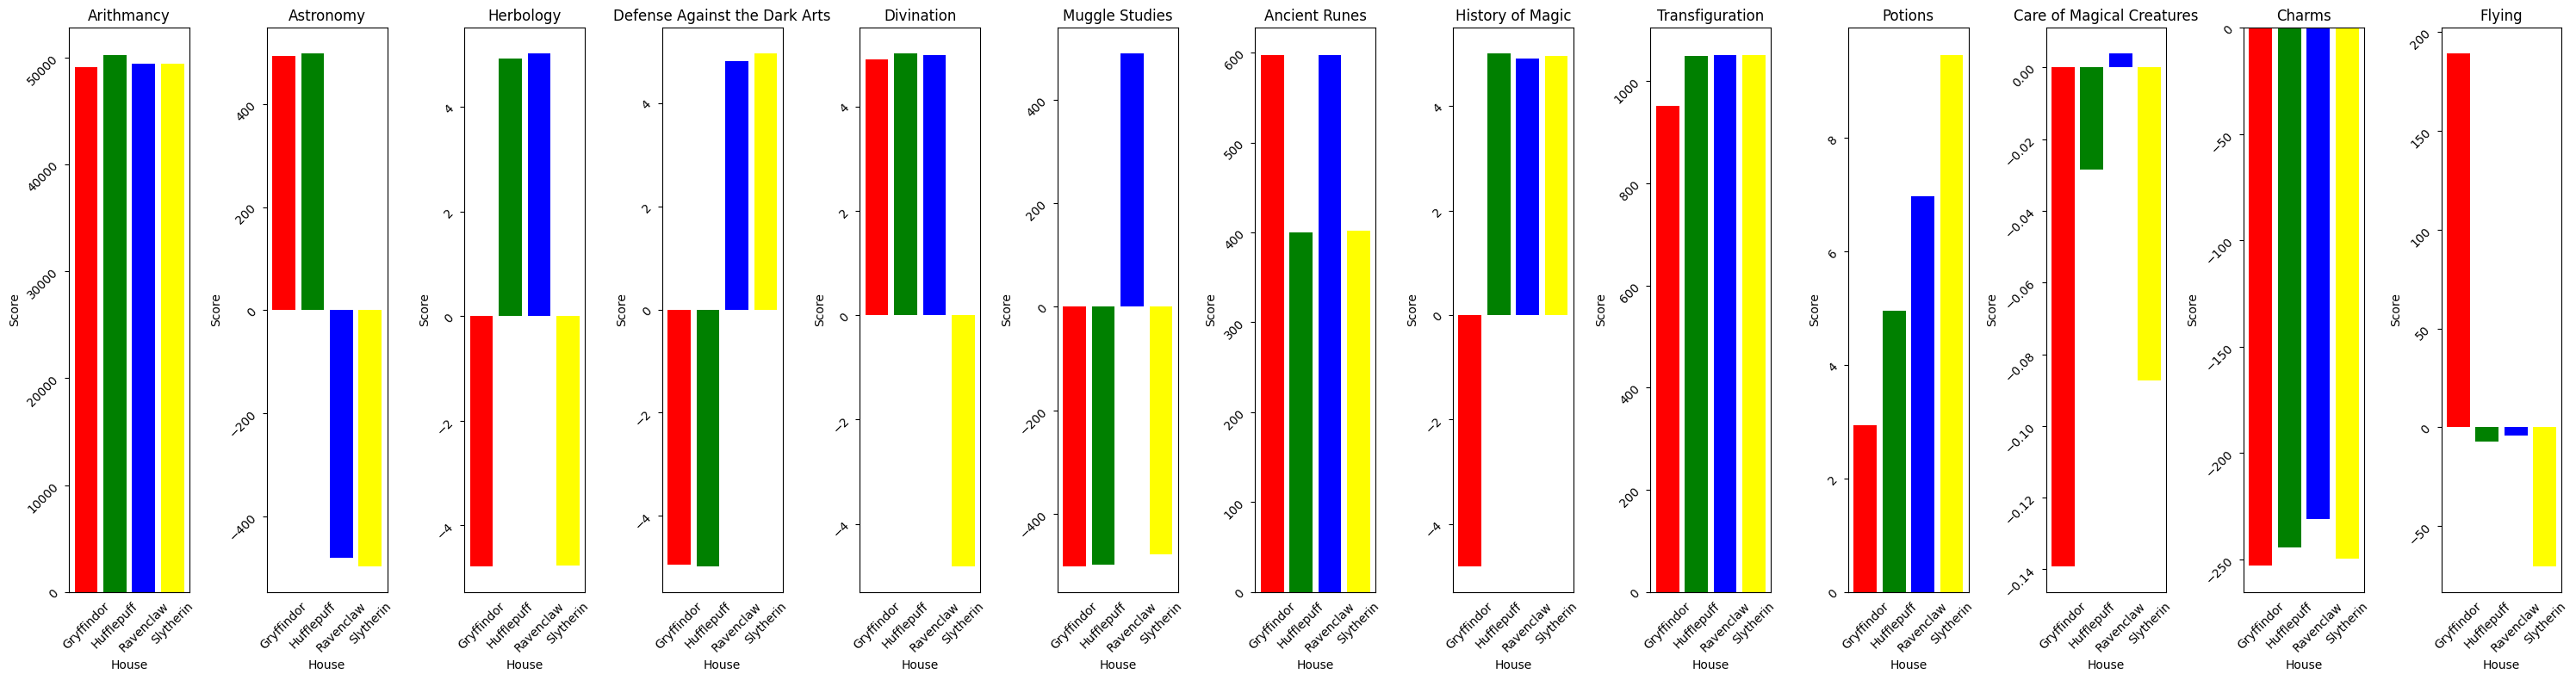

In [119]:
import matplotlib.pyplot as plt

def plot_histogram(df: pd.DataFrame):
    fig, ax = plt.subplots(1, 13, figsize=(30, 8))
    for i, course in enumerate(df.columns):
        ax[i].bar(df.index, df[course], color=['red', 'green', 'blue', 'yellow'])
        ax[i].set_title(course)
        ax[i].set_ylabel('Score')
        ax[i].set_xlabel('House')
        ax[i].tick_params(rotation=45)
        ax[i].xaxis.set_ticks_position('none')
    plt.tight_layout()
    plt.show()
    
plot_histogram(scores)